# Рубежный контроль №1

**Вариант:** 17  
**Задача:** №3  
**Набор данных:** №1, Iris (`sklearn.datasets.load_iris`)

**Ф.И.О.:** Талаев Андрей Петрович  
**Группа:** ИУ5-65Б

## 1. Импорт библиотек и загрузка данных

В наборе Iris четыре количественных признака цветка и целевой признак
с видом ириса. Для демонстрации кодирования категориального признака
целевой признак преобразован в текстовую колонку `species`.

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

pd.set_option("display.precision", 4)

In [2]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns=["target"])

print(f"Размер набора данных: {df.shape[0]} строк, {df.shape[1]} признаков")
df.head()

Размер набора данных: 150 строк, 5 признаков


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Пропусков в исходном наборе данных нет. Колонки с размерами цветка имеют
тип `float64`, а колонка `species` является категориальной.

## 2. Масштабирование одного количественного признака

Для масштабирования выбран признак `sepal length (cm)`. Используется
`StandardScaler`, который преобразует значения по формуле:

$$
x_{scaled} = \frac{x - \bar{x}}{s}
$$

После такого преобразования среднее значение признака становится близко
к 0, а стандартное отклонение - к 1.

In [5]:
feature_to_scale = "sepal length (cm)"

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[f"{feature_to_scale}_standard_scaled"] = scaler.fit_transform(
    df[[feature_to_scale]]
)

df_scaled[[feature_to_scale, f"{feature_to_scale}_standard_scaled"]].head(10)

,sepal length (cm),sepal length (cm)_standard_scaled
0,5.1,-0.9007
1,4.9,-1.1430
2,4.7,-1.3854
3,4.6,-1.5065
4,5.0,-1.0218
5,5.4,-0.5372
6,4.6,-1.5065
7,5.0,-1.0218
8,4.4,-1.7489
9,4.9,-1.1430


In [6]:
pd.DataFrame(
    {
        "before_scaling": df[feature_to_scale].describe(),
        "after_standard_scaling": df_scaled[
            f"{feature_to_scale}_standard_scaled"
        ].describe(),
    }
)

,before_scaling,after_standard_scaling
count,150.0000,1.5000e+02
mean,5.8433,-4.7370e-16
std,0.8281,1.0034e+00
min,4.3000,-1.8700e+00
25%,5.1000,-9.0068e-01
50%,5.8000,-5.2506e-02
75%,6.4000,6.7450e-01
max,7.9000,2.4920e+00


`StandardScaler` выбран потому, что он подходит для алгоритмов, чувствительных
к масштабу признаков: методов ближайших соседей, линейных моделей,
SVM, кластеризации и градиентных методов оптимизации. Для деревьев решений
и ансамблей на их основе масштабирование обычно не является обязательным.

## 3. Label Encoding для категориального признака

Для кодирования выбран категориальный признак `species`.
`LabelEncoder` заменяет каждую категорию целым числом.

In [7]:
label_encoder = LabelEncoder()

df_label_encoded = df.copy()
df_label_encoded["species_label_encoded"] = label_encoder.fit_transform(
    df_label_encoded["species"]
)

label_mapping = pd.DataFrame(
    {
        "species": label_encoder.classes_,
        "label": range(len(label_encoder.classes_)),
    }
)

label_mapping

,species,label
0,setosa,0
1,versicolor,1
2,virginica,2


In [8]:
df_label_encoded[["species", "species_label_encoded"]].drop_duplicates()

,species,species_label_encoded
0,setosa,0
50,versicolor,1
100,virginica,2


`LabelEncoder` удобен, если категориальный признак является целевой
переменной классификации. Если использовать такое кодирование для входного
номинального признака, модель может ошибочно воспринять числа как порядок
категорий.

## 4. One Hot Encoding для категориального признака

Для той же колонки `species` используется `OneHotEncoder`. Каждая категория
превращается в отдельный бинарный признак.

In [9]:
one_hot_encoder = OneHotEncoder(sparse_output=False, dtype=int)

one_hot_values = one_hot_encoder.fit_transform(df[["species"]])
one_hot_columns = one_hot_encoder.get_feature_names_out(["species"])

df_one_hot = pd.concat(
    [
        df,
        pd.DataFrame(one_hot_values, columns=one_hot_columns, index=df.index),
    ],
    axis=1,
)

df_one_hot[["species", *one_hot_columns]].drop_duplicates()

,species,species_setosa,species_versicolor,species_virginica
0,setosa,1,0,0
50,versicolor,0,1,0
100,virginica,0,0,1


In [10]:
df_one_hot.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,setosa,1,0,0
1,4.9,3.0,1.4,0.2,setosa,1,0,0
2,4.7,3.2,1.3,0.2,setosa,1,0,0
3,4.6,3.1,1.5,0.2,setosa,1,0,0
4,5.0,3.6,1.4,0.2,setosa,1,0,0


`OneHotEncoder` лучше подходит для номинальных входных признаков, потому что
не создает искусственного порядка между категориями. Недостаток метода -
увеличение числа признаков, особенно если у категориальной колонки много
уникальных значений.

## 5. Итоговый набор после преобразований

Ниже сформирован итоговый датафрейм, в котором есть исходные числовые
признаки, масштабированный признак и one hot-кодирование категории.
Колонка `species` оставлена для наглядности.

In [11]:
result_df = pd.concat(
    [
        df_scaled,
        pd.DataFrame(one_hot_values, columns=one_hot_columns, index=df.index),
    ],
    axis=1,
)

result_df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal length (cm)_standard_scaled,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,setosa,-0.9007,1,0,0
1,4.9,3.0,1.4,0.2,setosa,-1.1430,1,0,0
2,4.7,3.2,1.3,0.2,setosa,-1.3854,1,0,0
3,4.6,3.1,1.5,0.2,setosa,-1.5065,1,0,0
4,5.0,3.6,1.4,0.2,setosa,-1.0218,1,0,0
5,5.4,3.9,1.7,0.4,setosa,-0.5372,1,0,0
6,4.6,3.4,1.4,0.3,setosa,-1.5065,1,0,0
7,5.0,3.4,1.5,0.2,setosa,-1.0218,1,0,0
8,4.4,2.9,1.4,0.2,setosa,-1.7489,1,0,0
9,4.9,3.1,1.5,0.1,setosa,-1.1430,1,0,0


In [12]:
result_df.describe(include="all")

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,sepal length (cm)_standard_scaled,species_setosa,species_versicolor,species_virginica
count,150.0000,150.0000,150.0000,150.0000,150,1.5000e+02,150.0000,150.0000,150.0000
unique,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,setosa,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,50,NaN,NaN,NaN,NaN
mean,5.8433,3.0573,3.7580,1.1993,NaN,-4.7370e-16,0.3333,0.3333,0.3333
std,0.8281,0.4359,1.7653,0.7622,NaN,1.0034e+00,0.4730,0.4730,0.4730
min,4.3000,2.0000,1.0000,0.1000,NaN,-1.8700e+00,0.0000,0.0000,0.0000
25%,5.1000,2.8000,1.6000,0.3000,NaN,-9.0068e-01,0.0000,0.0000,0.0000
50%,5.8000,3.0000,4.3500,1.3000,NaN,-5.2506e-02,0.0000,0.0000,0.0000
75%,6.4000,3.3000,5.1000,1.8000,NaN,6.7450e-01,1.0000,1.0000,1.0000


## 6. Парные диаграммы

Для Iris удобно показать попарные
связи четырех числовых признаков и выделить виды ирисов цветом.

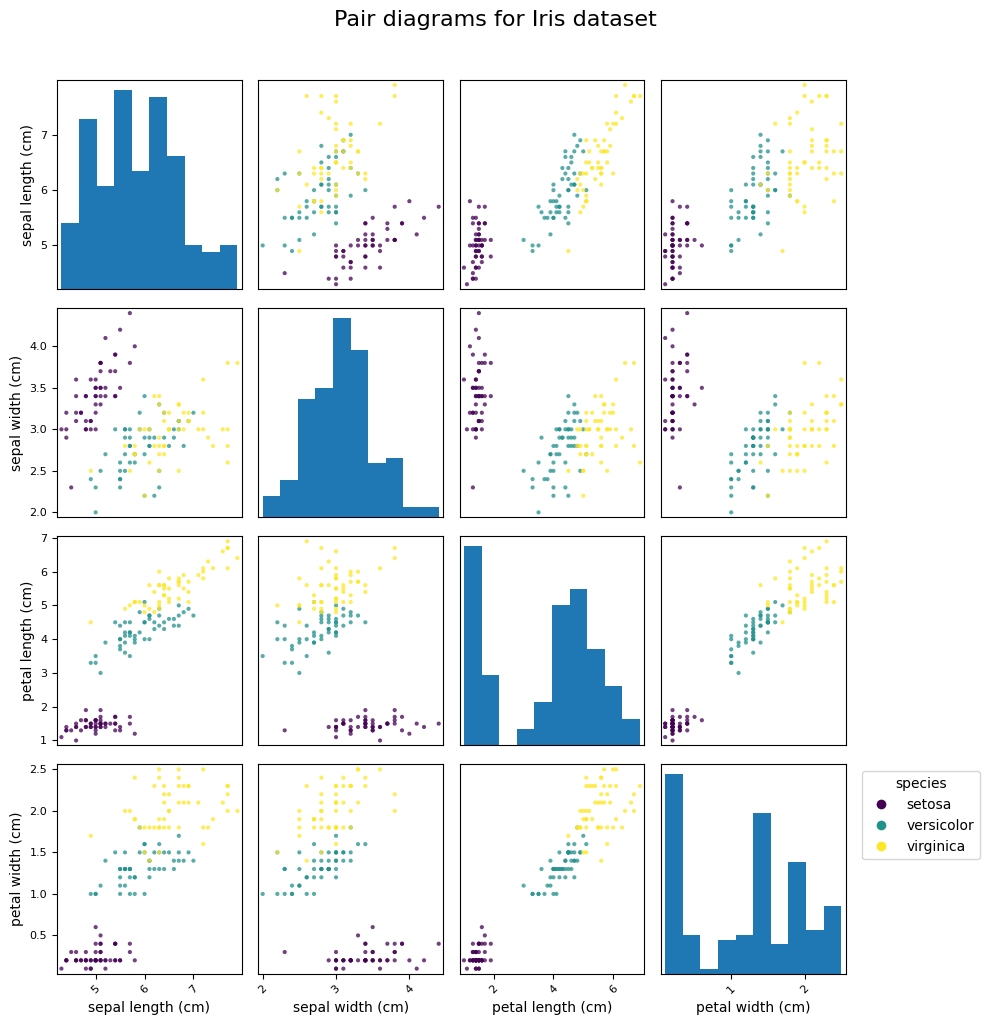

In [13]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

numeric_iris = df.drop(columns=["species"])
species_codes = df["species"].astype("category").cat.codes
species_names = df["species"].astype("category").cat.categories

axes = scatter_matrix(
    numeric_iris,
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.75,
    c=species_codes,
    cmap="viridis",
    grid=True,
)

for ax in axes.ravel():
    ax.tick_params(axis="x", labelrotation=45)
    ax.tick_params(axis="y", labelsize=8)

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=plt.cm.viridis(i / (len(species_names) - 1)),
        markersize=8,
        label=species,
    )
    for i, species in enumerate(species_names)
]

plt.legend(
    handles=handles,
    title="species",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.suptitle("Pair diagrams for Iris dataset", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

Парные диаграммы показывают, что класс `setosa` хорошо отделяется
от остальных видов по признакам длины и ширины лепестка. Виды
`versicolor` и `virginica` частично пересекаются, но между ними
также заметна разница по `petal length (cm)` и `petal width (cm)`.
Эти признаки могут быть особенно полезны при построении модели
классификации.

## Выводы

1. Для признака `sepal length (cm)` выполнено масштабирование методом
`StandardScaler`. После преобразования среднее значение стало близко к 0,
а стандартное отклонение - к 1. Такое масштабирование полезно для моделей,
чувствительных к расстояниям и величинам коэффициентов.

2. Для категориального признака `species` выполнено кодирование методом
`LabelEncoder`: категории `setosa`, `versicolor`, `virginica` заменены
целыми числами. Этот способ уместен для кодирования целевой переменной,
но может быть нежелателен для номинального входного признака из-за
появления искусственного порядка.

3. Для признака `species` также выполнено `OneHotEncoder`-кодирование.
Метод создал отдельные бинарные признаки для каждого вида ириса и не
задает ложной упорядоченности категорий.

4. Если строить модель для предсказания вида ириса, колонку `species`
нельзя использовать как входной признак, так как это привело бы к утечке
целевой переменной. В этом случае `LabelEncoder` можно использовать для
подготовки целевого признака, а масштабирование - для числовых признаков
перед применением чувствительных к масштабу алгоритмов.